In [17]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [13]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

#  Se agrega canal debido a que el dataset es en escala de grises. (28,28) -> (28,28,1)
# CNN necesita 3 dimensiones para las imágenes (alto, ancho, canales)
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

print(X_train.shape)
print(X_test.shape)

# Convertir las etiquetas a formato one-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [14]:
# Definir el modelo de la red neuronal convolucional
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),  # Capa de MaxPooling con tamaño de 2x2
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),  # Segunda capa de MaxPooling
    Conv2D(128, (3, 3), activation='relu'),
    Flatten(),  # Aplanar la salida para la capa completamente conectada
    Dense(128, activation='relu'),  # Capa totalmente conectada con 128 neuronas
    Dropout(0.5),  # Dropout para reducir el sobreajuste
    Dense(10, activation='softmax')
])

# Compilar el modelo
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Entrenar el modelo
history = model.fit(X_train, y_train, epochs=20, batch_size=64, validation_data=(X_test, y_test), verbose=1)


Epoch 1/20


c:\Users\Natalia\Desktop\Universidad7\Deep-Learning\2\.venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7760 - loss: 0.6173 - val_accuracy: 0.8574 - val_loss: 0.3930
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8633 - loss: 0.3846 - val_accuracy: 0.8738 - val_loss: 0.3365
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8814 - loss: 0.3313 - val_accuracy: 0.8953 - val_loss: 0.2927
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8946 - loss: 0.2968 - val_accuracy: 0.8937 - val_loss: 0.2880
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9021 - loss: 0.2693 - val_accuracy: 0.9026 - val_loss: 0.2707
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9105 - loss: 0.2502 - val_accuracy: 0.9035 - val_loss: 0.2623
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9158 - loss: 0.2310 - val_accuracy: 0.9058 - val_loss: 0.2616
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9236 - loss: 0.2112 - val_accuracy: 0.9105 - val_

Exactitud en el conjunto de prueba: 0.91


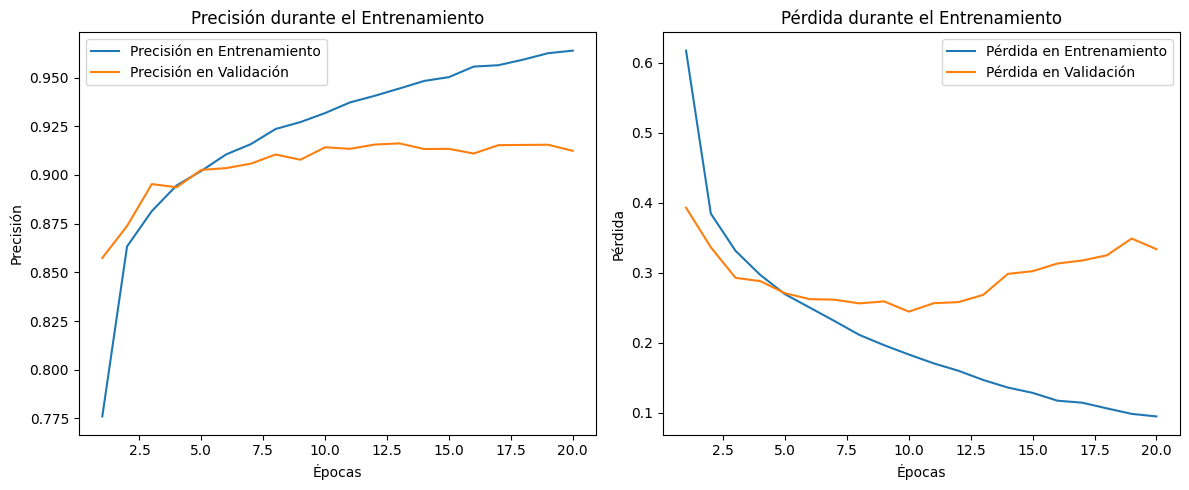

In [19]:
# Evaluar el modelo en el conjunto de prueba
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Exactitud en el conjunto de prueba: {test_acc:.2f}")

# Graficar la precisión y la pérdida del entrenamiento
epochs = range(1, len(history.history['accuracy']) + 1)

plt.figure(figsize=(12, 5))

# Gráfico de la precisión
plt.subplot(1, 2, 1)
plt.plot(epochs, history.history['accuracy'], label='Precisión en Entrenamiento')
plt.plot(epochs, history.history['val_accuracy'], label='Precisión en Validación')
plt.title('Precisión durante el Entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()

# Gráfico de la pérdida
plt.subplot(1, 2, 2)
plt.plot(epochs, history.history['loss'], label='Pérdida en Entrenamiento')
plt.plot(epochs, history.history['val_loss'], label='Pérdida en Validación')
plt.title('Pérdida durante el Entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()

plt.tight_layout()
plt.show()

In [20]:
# Realizar predicciones en el conjunto de prueba
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


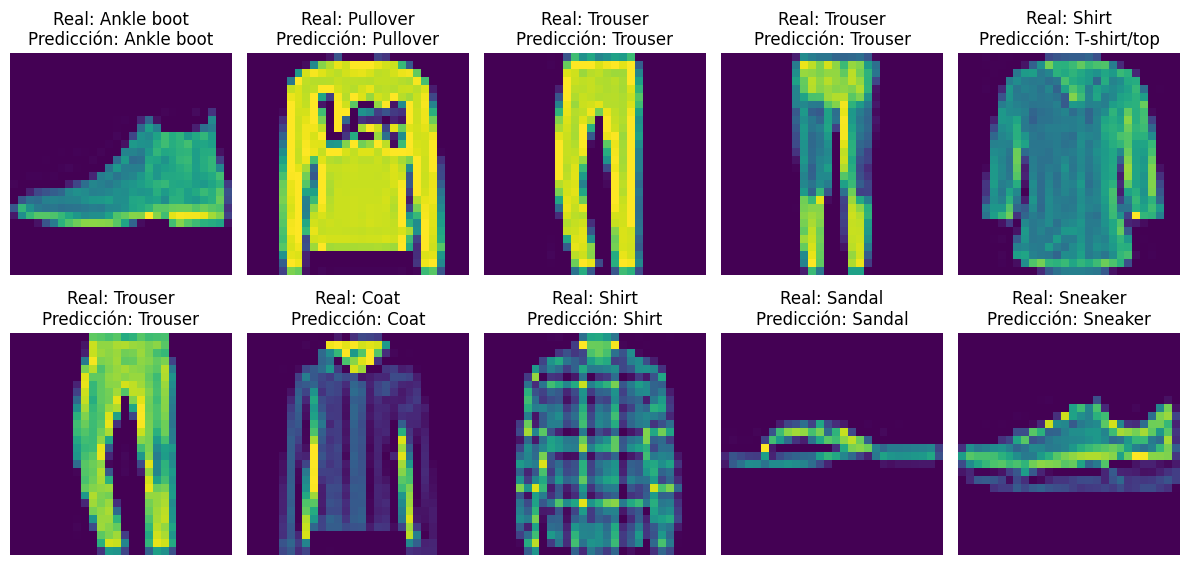

In [ ]:
#print("clases de prueba", np.argmax(y_test,axis=1))

# Diccionario de clases para Fashion MNIST
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
#print(f"Real: {class_names[int(y_test[1][0])]}\nPredicción: {class_names[y_pred_classes[1]]}")

# Mostrar las primeras 10 imágenes del conjunto de prueba junto con sus predicciones
plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[i])
    plt.title(f"Real: {class_names[y_test[i]]}\nPredicción: {class_names[y_pred_classes[i]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()